# TMDB Movies Analysis

## Introduction
In this project, I perform an exploratory data analysis (EDA) on the TMDB movie dataset. The goal of this analysis is to understand the factors that are associated with higher movie revenue.

Exploratory Data Analysis is used to summarize the main characteristics of the dataset using statistical summaries and visualizations. The analysis will begin with single-variable exploration (univariate analysis), then move to examining relationships between variables (bivariate and multivariate analysis).


## Research Questions


How is movie revenue distributed?

Is there a relationship between movie budget and revenue?

Is movie popularity associated with higher revenue?

How do budget and popularity together relate to revenue?

## Data Wrangling

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("tmdb-movies.csv")

# Display first rows to understand structure
df.head(1)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09


## Assessing Data

Before performing analysis, I will:

- Check missing values

- Remove unnecessary columns

- Drop rows with missing critical values (budget, revenue)

- Remove rows with zero budget or revenue


In [101]:
# Check missing values
df.isnull().sum()

# Keep only relevant columns
df = df[['budget', 'revenue', 'popularity', 'release_year']]

# Drop missing values
df.dropna(inplace=True)

# Remove zero values for budget and revenue
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3855 entries, 0 to 10848
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        3855 non-null   int64  
 1   revenue       3855 non-null   int64  
 2   popularity    3855 non-null   float64
 3   release_year  3855 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 150.6 KB


### Create Required Function

In [104]:
def add_labels(title, xlabel, ylabel):
    """
    This function adds title and axis labels to plots
    to avoid repetitive code.
    """
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)


## Exploratory Data Analysis

### Univariate Analysis
#### Question 1: How is revenue distributed?

To understand how revenue behaves in the dataset, I will visualize its distribution. This helps identify whether most movies generate similar revenue or if only a few generate extremely high revenue.

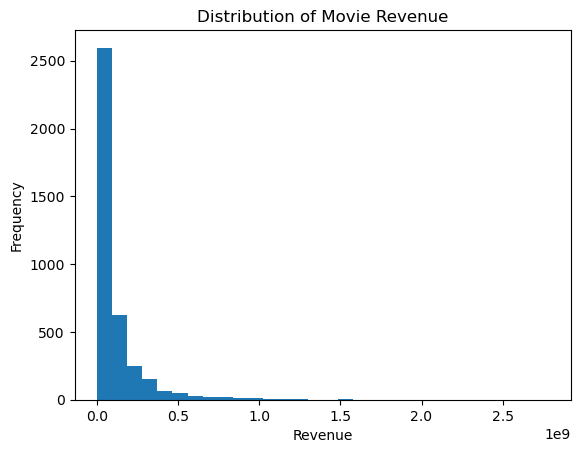

In [147]:
# Create histogram to visualize the distribution of movie revenue
plt.hist(df['revenue'], bins=30)

# Add title and axis labels using the custom labeling function
add_labels('Distribution of Movie Revenue', 'Revenue', 'Frequency')

# Display the plot
plt.show()

#### Interpretation 

The histogram shows that revenue is right-skewed. Most movies generate relatively low revenue, while a small number of movies generate extremely high revenue. This indicates the presence of outliers.

In [110]:
df['profit'] = df['revenue'] - df['budget']

#### Univariate Analysis: Budget Distribution

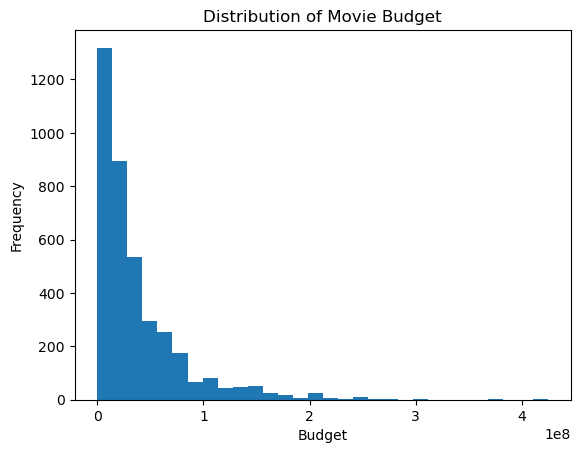

In [145]:
# Create histogram to visualize distribution of movie budgets
plt.hist(df['budget'], bins=30)

# Add title and axis labels using the custom function
add_labels('Distribution of Movie Budget', 'Budget', 'Frequency')

# Display the plot
plt.show()

#### Interpretation

The budget distribution is also right-skewed, meaning that most movies have relatively modest budgets, while a few movies have extremely high production budgets.

### Bivariate Analysis (2D)
#### Question 2: Is there a relationship between budget and revenue?

To explore whether higher budgets are associated with higher revenues, I will create a scatter plot.

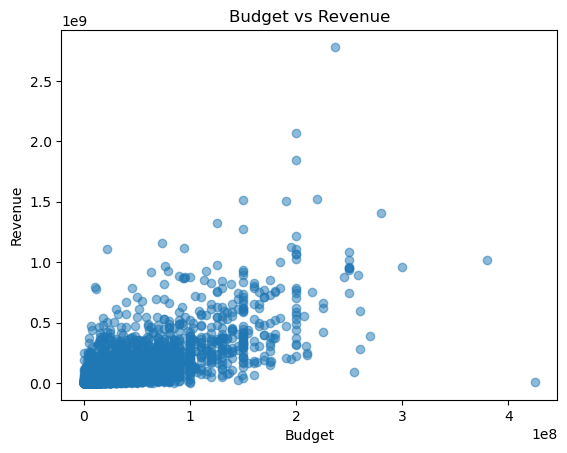

In [123]:
plt.scatter(df['budget'], df['revenue'], alpha=0.5)
add_labels('Budget vs Revenue', 'Budget', 'Revenue')
plt.show()

#### Interpretation

The scatter plot shows a positive relationship between budget and revenue. Movies with higher budgets tend to generate higher revenues.

However, this is a correlation and does not imply causation. High budget does not necessarily cause high revenue, as other factors may influence movie performance.

#### Question 3: Popularity vs Revenue

Popularity may reflect audience interest. I want to see if more popular movies generate more revenue.

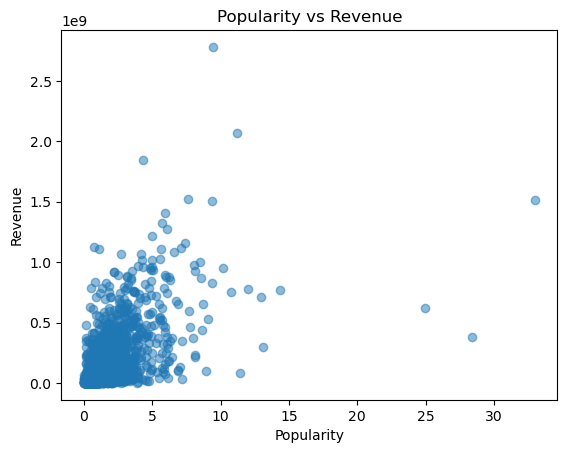

In [127]:
plt.scatter(df['popularity'], df['revenue'], alpha=0.5)
add_labels('Popularity vs Revenue', 'Popularity', 'Revenue')
plt.show()

#### Interpretation

There appears to be a positive relationship between popularity and revenue. Movies with higher popularity scores tend to generate higher revenues.
Again, this suggests correlation but not causation.

### Multivariate Analysis (3 Variables)
#### Question 4: Budget and Popularity Together

To better understand the relationship, I will examine how budget and popularity together relate to revenue.

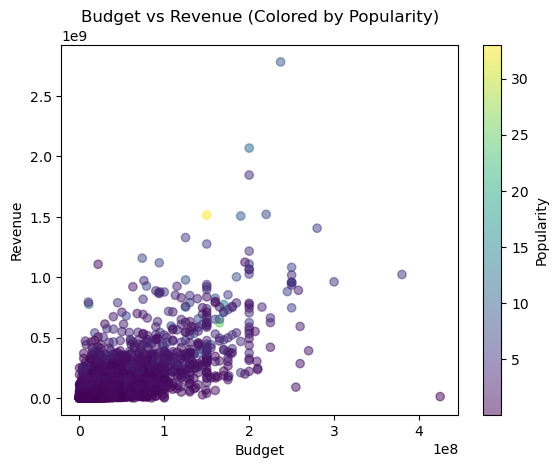

In [131]:
plt.scatter(df['budget'], df['revenue'], 
            c=df['popularity'], alpha=0.5)
add_labels('Budget vs Revenue (Colored by Popularity)', 'Budget', 'Revenue')
plt.colorbar(label='Popularity')
plt.show()

#### Interpretation
The plot suggests that movies with both high budgets and high popularity tend to generate the highest revenues. This indicates that multiple factors together may influence financial success.

## Conclusions
This analysis explored factors associated with higher movie revenue.

Main findings:

1. Revenue and budget distributions are highly right-skewed.

2. There is a positive correlation between budget and revenue.

3. Popularity is also positively associated with revenue.

4. Movies with both high budget and high popularity tend to generate the highest revenues.

It is important to note that these findings are based on correlation analysis and do not imply causation.

## Limitations

1. The dataset may contain missing or inaccurate data.

2. Inflation adjustments were not applied to budget or revenue.

3. Other important factors such as genre, cast, and marketing were not included.

4. The dataset is limited to specific years and movies included in TMDB.

Future research could include:

- Adjusting for inflation

- Including genre analysis

- Studying profitability (revenue - budget)

- Applying regression models for deeper insights